### Import required dependencies / packages 

In [247]:
# Before importing any dependencies please install thr required dependencies
import pandas as pd
from nepali_datetime import date as nepali_date
import seaborn as sns
import matplotlib.pyplot as plt

### Import sample stock data

In [248]:
data = pd.read_csv("sample_data.csv")

### Converting data into data frame

In [249]:
df = pd.DataFrame(data)

In [250]:
df.head() # displaying 5 items from start use df.tail() to display items from last

,open,high,low,close,volume,timestamp
0,112.00,118.00,112.00,118.00,60,1491177600
1,119.33,126.00,119.33,126.00,60,1491264000
2,126.00,134.67,127.33,134.67,70,1491436800
3,136.67,144.67,136.67,136.67,10050,1491696000
4,146.67,155.33,146.67,155.33,1060,1491782400


### Converting timestamp to english date and Get nepali date month day etc using nepali_datetime package

In [251]:
# Converting Timestamp to English date
df['date'] = pd.to_datetime(df['timestamp'],unit = 's') #converting timestamp to date
df['month'] = df['date'].dt.month_name() #getting month name from converted date i.e df['date']
df['day'] = df['date'].dt.day #getting day from converted date
df['weekday'] = df['date'].dt.day_name() #getting weekday like sunday,monday etc from converted date

# Converting English Date to nepali date using nepali_datetime
df['nep_date'] = df['date'].apply(lambda x: nepali_date.from_datetime_date(x.date())) #converting eng date to nepali date using nepali_dateTime
df['nep_year'] = df['nep_date'].apply(lambda x: x.year) #getting year from nepali date
df['nep_month'] = df['nep_date'].apply(lambda x: x.strftime('%B')) # getting month from nepali date
df['nep_day'] = df['nep_date'].apply(lambda x: x.day) # getting day from nepali date

In [252]:
df.head()

,open,high,low,close,volume,timestamp,date,month,day,weekday,nep_date,nep_year,nep_month,nep_day
0,112.00,118.00,112.00,118.00,60,1491177600,2017-04-03,April,3,Monday,2073-12-21,2073,Chaitra,21
1,119.33,126.00,119.33,126.00,60,1491264000,2017-04-04,April,4,Tuesday,2073-12-22,2073,Chaitra,22
2,126.00,134.67,127.33,134.67,70,1491436800,2017-04-06,April,6,Thursday,2073-12-24,2073,Chaitra,24
3,136.67,144.67,136.67,136.67,10050,1491696000,2017-04-09,April,9,Sunday,2073-12-27,2073,Chaitra,27
4,146.67,155.33,146.67,155.33,1060,1491782400,2017-04-10,April,10,Monday,2073-12-28,2073,Chaitra,28


### Defining / Making data frame based on my choice add items inside df[['choice1','choice2']] and so on

In [253]:
df[['open','close','high','low','volume','date','month','day','weekday','nep_date','nep_month','nep_day']]

,open,close,high,low,volume,date,month,day,weekday,nep_date,nep_month,nep_day
0,112.00,118.00,118.00,112.00,60,2017-04-03,April,3,Monday,2073-12-21,Chaitra,21
1,119.33,126.00,126.00,119.33,60,2017-04-04,April,4,Tuesday,2073-12-22,Chaitra,22
2,126.00,134.67,134.67,127.33,70,2017-04-06,April,6,Thursday,2073-12-24,Chaitra,24
3,136.67,136.67,144.67,136.67,10050,2017-04-09,April,9,Sunday,2073-12-27,Chaitra,27
4,146.67,155.33,155.33,146.67,1060,2017-04-10,April,10,Monday,2073-12-28,Chaitra,28
...,...,...,...,...,...,...,...,...,...,...,...,...
2024,518.00,511.00,520.10,510.00,9908,2026-05-04,May,4,Monday,2083-01-21,Baishakh,21
2025,506.50,515.60,520.00,506.00,7207,2026-05-05,May,5,Tuesday,2083-01-22,Baishakh,22
2026,511.00,519.00,525.20,511.00,3962,2026-05-06,May,6,Wednesday,2083-01-23,Baishakh,23
2027,528.00,517.90,528.00,515.10,7152,2026-05-07,May,7,Thursday,2083-01-24,Baishakh,24


### Calculating gain / loss and its percentage based on sample stock data

In [254]:
## Calculating gain / loss amount
df['gain/loss'] = df['close']-df['open']

## Calculating gain / loss Label
df['type'] = df['gain/loss'].apply(lambda x: 'Gain' if x > 0 else ('Loss' if x < 0 else 'Neutral'))

# Calculating gain/loss percentage
df['%'] = (df['gain/loss'] / df['open'] * 100).round(2)

In [255]:
df.head()

,open,high,low,close,volume,timestamp,date,month,day,weekday,nep_date,nep_year,nep_month,nep_day,gain/loss,type,%
0,112.00,118.00,112.00,118.00,60,1491177600,2017-04-03,April,3,Monday,2073-12-21,2073,Chaitra,21,6.00,Gain,5.36
1,119.33,126.00,119.33,126.00,60,1491264000,2017-04-04,April,4,Tuesday,2073-12-22,2073,Chaitra,22,6.67,Gain,5.59
2,126.00,134.67,127.33,134.67,70,1491436800,2017-04-06,April,6,Thursday,2073-12-24,2073,Chaitra,24,8.67,Gain,6.88
3,136.67,144.67,136.67,136.67,10050,1491696000,2017-04-09,April,9,Sunday,2073-12-27,2073,Chaitra,27,0.00,Neutral,0.00
4,146.67,155.33,146.67,155.33,1060,1491782400,2017-04-10,April,10,Monday,2073-12-28,2073,Chaitra,28,8.66,Gain,5.90


### Categorizing gain / loss into percentage

In [256]:
def categorize_pct(pct):
    if pct >= 7:
        return '7%+ Gain'
    elif pct >= 5:
        return '5-7% Gain'
    elif pct >= 3:
        return '3-5% Gain'
    elif pct > 0:
        return '0-3% Gain'
    elif pct == 0:
        return 'Neutral'
    elif pct > -3:
        return '0-3% Loss'
    elif pct > -5:
        return '3-5% Loss'
    elif pct > -7:
        return '5-7% Loss'
    else:
        return '7%+ Loss'

df['pct_change'] = df['%'].apply(categorize_pct)

In [257]:
df.tail()

,open,high,low,close,volume,timestamp,date,month,day,weekday,nep_date,nep_year,nep_month,nep_day,gain/loss,type,%,pct_change
2024,518.0,520.1,510.0,511.0,9908,1777852800,2026-05-04,May,4,Monday,2083-01-21,2083,Baishakh,21,-7.0,Loss,-1.35,0-3% Loss
2025,506.5,520.0,506.0,515.6,7207,1777939200,2026-05-05,May,5,Tuesday,2083-01-22,2083,Baishakh,22,9.1,Gain,1.80,0-3% Gain
2026,511.0,525.2,511.0,519.0,3962,1778025600,2026-05-06,May,6,Wednesday,2083-01-23,2083,Baishakh,23,8.0,Gain,1.57,0-3% Gain
2027,528.0,528.0,515.1,517.9,7152,1778112000,2026-05-07,May,7,Thursday,2083-01-24,2083,Baishakh,24,-10.1,Loss,-1.91,0-3% Loss
2028,520.0,528.0,517.5,527.0,8510,1778198400,2026-05-08,May,8,Friday,2083-01-25,2083,Baishakh,25,7.0,Gain,1.35,0-3% Gain


### Grouping Values here I will be demonstrating based on percentage

In [258]:
df['pct_change'].value_counts() #use any column name to group test replacing/changing pct_change to nep_day etc

pct_change
0-3% Loss    736
0-3% Gain    558
Neutral      205
3-5% Loss    201
3-5% Gain    152
5-7% Gain     65
7%+ Gain      55
5-7% Loss     44
7%+ Loss      13
Name: count, dtype: int64

### Filtering date base on percentage like for eg gain by 5+-%

In [259]:
five_plus_per_gain_loss = df[df['%'].abs()>=5]

In [260]:
five_plus_per_gain_loss.tail()

,open,high,low,close,volume,timestamp,date,month,day,weekday,nep_date,nep_year,nep_month,nep_day,gain/loss,type,%,pct_change
1890,499.6,499.6,465.5,465.50,2390,1758153600,2025-09-18,September,18,Thursday,2082-06-02,2082,Aswin,2,-34.10,Loss,-6.83,5-7% Loss
1891,465.5,512.0,465.5,499.45,17352,1758412800,2025-09-21,September,21,Sunday,2082-06-05,2082,Aswin,5,33.95,Gain,7.29,7%+ Gain
1909,489.0,528.0,485.0,528.00,40270,1762041600,2025-11-02,November,2,Sunday,2082-07-16,2082,Kartik,16,39.00,Gain,7.98,7%+ Gain
1959,521.2,562.1,521.2,562.10,94746,1768694400,2026-01-18,January,18,Sunday,2082-10-04,2082,Magh,4,40.90,Gain,7.85,7%+ Gain
1960,573.3,618.3,573.3,618.30,186583,1768867200,2026-01-20,January,20,Tuesday,2082-10-06,2082,Magh,6,45.00,Gain,7.85,7%+ Gain


### Grouping data by nepali month day and weekday and sorting based on gain

In [261]:
filtered_data = df.groupby(['nep_month','nep_day','weekday'])['type'].value_counts().unstack(fill_value=0).sort_values('Gain',ascending = False)

In [262]:
filtered_data.head()

type                       Gain  Loss  Neutral
nep_month nep_day weekday                     
Shrawan   29      Tuesday     2     0        0
          28      Monday      2     0        0
Falgun    15      Tuesday     2     0        0
          18      Sunday      2     0        0
Asar      9       Monday      2     0        0

### Saving Filtered data to file name filtered_sample_stock_data.xlsx

In [263]:
filtered_data.to_excel("filtered_sample_stock_data.xlsx",freeze_panes=(1,0)) #freeze_panes(1,0) will freeze the first col i.e heading

### Ploting some data into heatmap for better visaulization

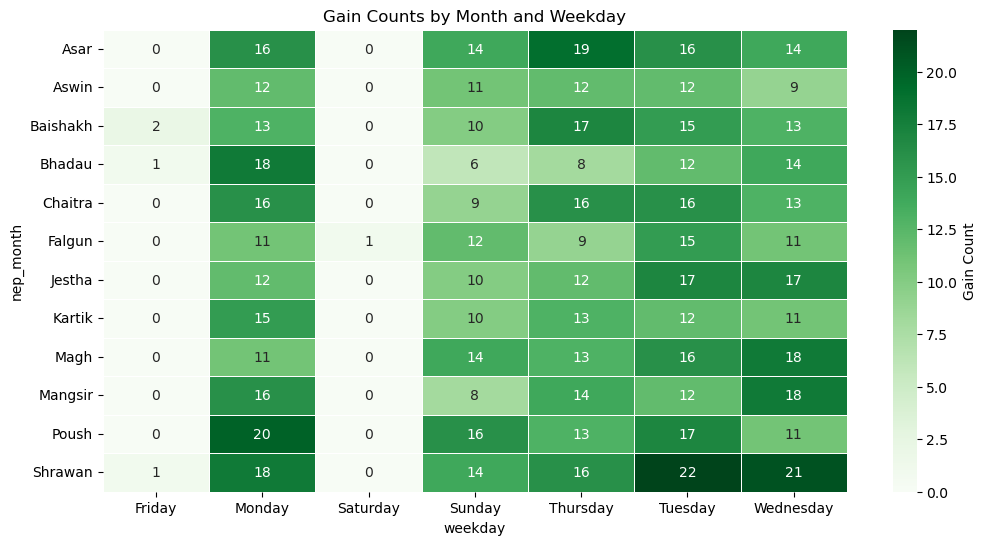

In [264]:
# Reset index to work with it easily
heatmap_data = filtered_data.reset_index()

# --- Heatmap 1: Gain by Month and Weekday ---
#---- Comment/Change values of  index, colums, values to see magic, test it once---------------
pivot_gain = heatmap_data.pivot_table(
    values = 'Gain',
    index = 'nep_month',
    columns = 'weekday',
    aggfunc = 'sum', #to count total we use aggfunc as sum you can make it optional
    fill_value = 0
)
plt.figure(figsize = (12,6))
sns.heatmap(
    pivot_gain,
    annot = True, #to show numbers optional
    cmap = 'Greens', #to change default color to green optional
    linewidth =0.5, # to show line width optional
    cbar_kws = {"label":"Gain Count"} # to show label on gain count optional
)

# To set Title but optional
plt.title('Gain Counts by Month and Weekday')

# To fill according to screen size use based on your needs
# plt.tight_layout()

# To save image that is plot *Note: Please save image before you show image otherwise it won't save
plt.savefig("Gain_Count_HeatMap.png")
plt.show()

### Lets Plot / See Gain data of one specific month
##### For Reference we are using moth of jestha 

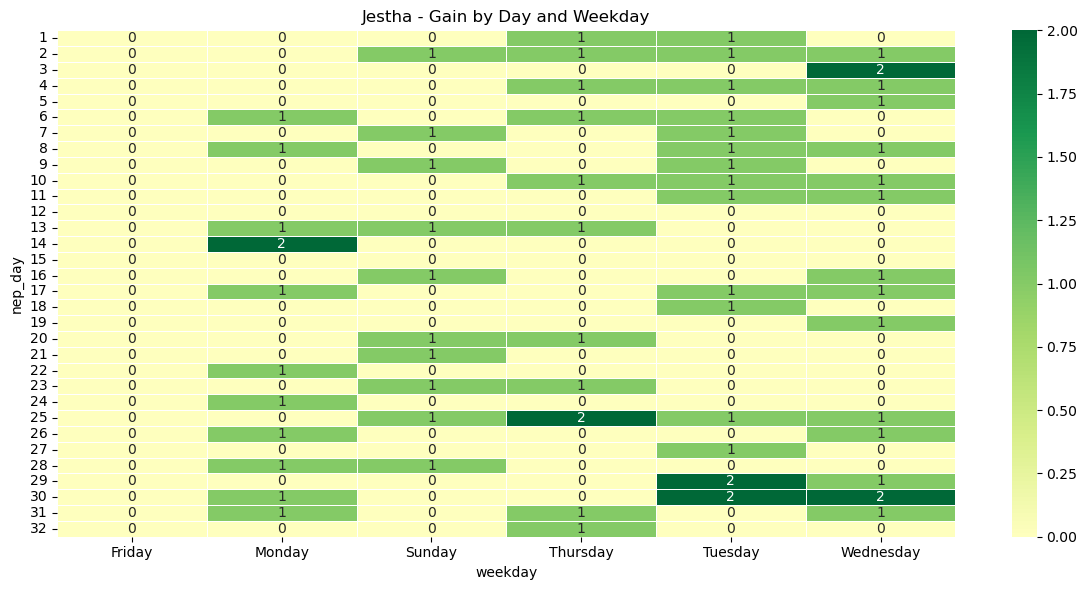

In [265]:
## Filtering data from above heatmap_data for moth jestha
filtered_jestha = heatmap_data[heatmap_data['nep_month']=='Jestha']
pivot_gain = filtered_jestha.pivot_table(
    values = 'Gain',
    index = 'nep_day',
    columns = 'weekday',
    aggfunc = 'sum',
    fill_value = 0,
)

plt.figure(figsize = (12,6))
sns.heatmap(
    pivot_gain,
    cmap = 'RdYlGn',
    annot = True,
    center = 0,
    linewidths = 0.5
)
plt.title('Jestha - Gain by Day and Weekday')
plt.tight_layout()
plt.savefig('Jestha_Gain_Count_Heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Now Plotting both gain / loss data on single heatmap

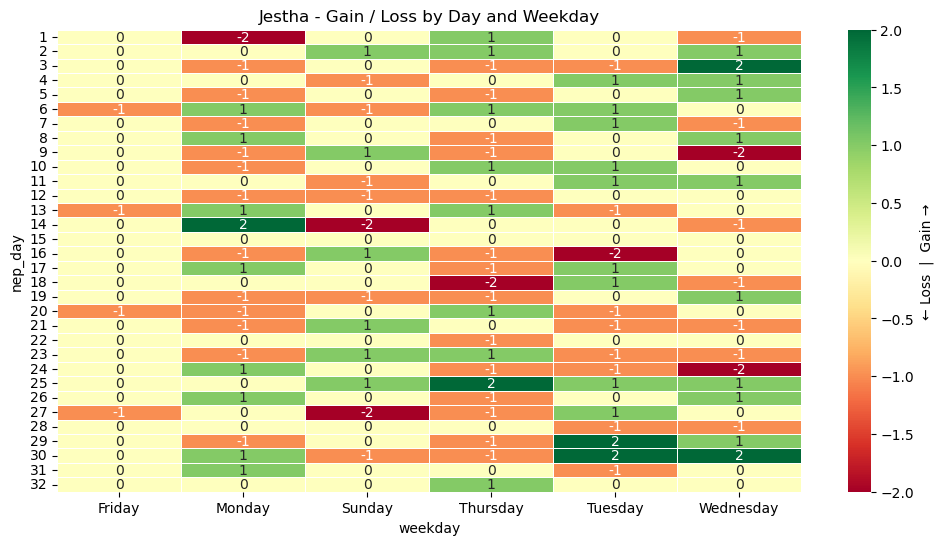

In [266]:
# filtered_jestha_gl = heatmap_data[heatmap_data['nep_month']=='Jestha'].copy
filtered_jestha['net'] = filtered_jestha['Gain']-filtered_jestha['Loss']
pivot_net = filtered_jestha.pivot_table(
    values = 'net',
    index = 'nep_day',
    columns = 'weekday',
    aggfunc = 'sum',
    fill_value = 0
)

plt.figure(figsize = (12,6))

sns.heatmap(
    pivot_net,
    annot = True,
    cmap='RdYlGn',   # red = loss dominant, green = gain dominant
    center=0,         
    linewidths=0.5,
    cbar_kws={'label': '← Loss  |  Gain →'}
)

plt.title('Jestha - Gain / Loss by Day and Weekday')
plt.savefig('Jestha_Gain_Loss_Count_Heatmap.png', dpi=200, bbox_inches='tight')
plt.show()